# 04 - Uncertainty and deep ensembles

**Goal.** Make a model say "I do not know", and understand exactly what that means.
We separate the two kinds of predictive uncertainty, connect ensembles to Bayesian
inference, estimate uncertainty from scratch with numpy, then test whether it is
*calibrated* - and see the failure mode (uncertainty is not error) that the rest of
the course is built to catch.

## 1. Two uncertainties, via the law of total variance

Let a model with parameters $\theta$ define $p(y\mid x,\theta)$, and let $p(\theta\mid D)$
be the posterior after seeing data $D$. The predictive variance decomposes exactly
by the **law of total variance**:

$$ \underbrace{\mathrm{Var}(y\mid x)}_{\text{predictive}}
 = \underbrace{\mathbb E_{\theta}\!\big[\mathrm{Var}(y\mid x,\theta)\big]}_{\text{aleatoric}}
 + \underbrace{\mathrm{Var}_{\theta}\!\big(\mathbb E[y\mid x,\theta]\big)}_{\text{epistemic}} . $$

- **Aleatoric** uncertainty is the *expected data noise* - irreducible, present even
  with a perfect model; more data does not shrink it [1,2,3].
- **Epistemic** uncertainty is the *spread of model predictions* under the posterior
  - it is the model's ignorance, and it *does* shrink with more data. It is largest
  where the training set was sparse, i.e. out of distribution.

For safety, epistemic uncertainty is the interesting one: it is what should rise
when the vehicle enters an unfamiliar regime.

## 2. The Bayesian predictive, and why ensembles approximate it

The quantity we actually want is the **posterior predictive**, marginalising over
all plausible parameters:

$$ p(y\mid x, D) = \int p(y\mid x,\theta)\,p(\theta\mid D)\,\mathrm d\theta . $$

For a neural network $p(\theta\mid D)$ is intractable, so we approximate it - by a
Laplace approximation [4], MC dropout [5], variational inference [6], or a
**deep ensemble** [7]. A deep ensemble trains $M$ models from different random
initialisations (and/or data resamples) and treats the resulting parameters
$\{\theta_i\}$ as samples of the posterior:

$$ p(y\mid x,D) \approx \frac1M\sum_{i=1}^M p(y\mid x,\theta_i). $$

Empirically ensembles are among the strongest uncertainty methods: independent SGD
runs land in *different* modes of the loss landscape, giving genuine
**function-space diversity** rather than small wiggles around one mode [7,8].

## 3. The estimator

With $M$ member predictions $\hat y_i(x)$ (each optionally also predicting a noise
variance $\hat\sigma_i^2(x)$ for the aleatoric part), the ensemble reports

$$ \bar y(x)=\frac1M\sum_i \hat y_i(x),\qquad
   \Sigma^{epi}(x)=\frac{1}{M-1}\sum_i\big(\hat y_i(x)-\bar y(x)\big)\big(\hat y_i(x)-\bar y(x)\big)^\top, $$

and the total predictive variance follows the decomposition of section 1,

$$ \sigma^2_{tot}(x)=\underbrace{\tfrac1M\textstyle\sum_i \hat\sigma_i^2(x)}_{\text{aleatoric}}
   +\underbrace{\mathrm{Var}_i\big(\hat y_i(x)\big)}_{\text{epistemic}} . $$

In the driving system, $\Sigma^{epi}$ is exactly the perception covariance
$\Sigma^{AI}$ whose trace feeds the integrity score (notebook 06). Let us build one
from scratch. We use random-feature ridge regressors as cheap "networks" [12]; the
diversity comes from different random features per member plus a bootstrap resample.

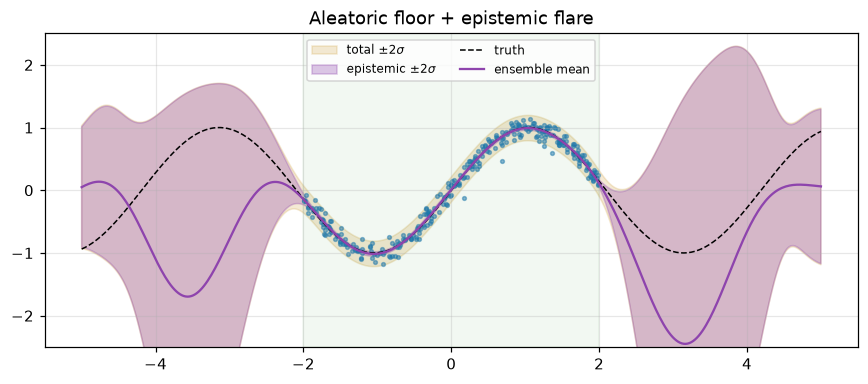

aleatoric std  sqrt(sig_a2)     = 0.100   (true label noise 0.10)
epistemic std  in [-2,2]        = 0.017
epistemic std  in |x|>3 (OOD)   = 1.314


In [1]:
import numpy as np, matplotlib.pyplot as plt
from math import erf, sqrt
rng = np.random.default_rng(0)

f = lambda x: np.sin(1.5*x)                       # ground-truth function
noise = 0.1                                       # aleatoric label noise (std)
Xtr = rng.uniform(-2, 2, 300); Ytr = f(Xtr) + rng.normal(0, noise, 300)
Xval = rng.uniform(-2, 2, 300); Yval = f(Xval) + rng.normal(0, noise, 300)

def features(D, seed, scale=1.5):
    r = np.random.default_rng(seed)
    Wf, bf = r.normal(0, scale, (D, 1)), r.uniform(0, 2*np.pi, D)
    return lambda x: np.cos(x.reshape(-1, 1) @ Wf.T + bf)

def fit_member(phi, X, Y, lam=1e-2):
    P = phi(X); w = np.linalg.solve(P.T@P + lam*np.eye(P.shape[1]), P.T@Y)
    return lambda x: phi(x) @ w

M = 25
members = []
for s in range(M):
    phi = features(200, seed=1000 + s)            # init diversity: different random features
    idx = rng.integers(0, len(Xtr), len(Xtr))     # data diversity: bootstrap resample
    members.append(fit_member(phi, Xtr[idx], Ytr[idx]))

preds    = lambda x: np.stack([m(x) for m in members])   # (M, N)
ens_mean = lambda x: preds(x).mean(0)
ens_epi  = lambda x: preds(x).var(0)
sig_a2   = float(np.mean((Yval - ens_mean(Xval))**2))     # aleatoric estimate (held-out residual)

xs = np.linspace(-5, 5, 400)
mu, epi = ens_mean(xs), ens_epi(xs); tot = epi + sig_a2
plt.figure(figsize=(8, 3.6))
plt.fill_between(xs, mu-2*np.sqrt(tot), mu+2*np.sqrt(tot), color="#c68a12", alpha=.18, label="total $\\pm2\\sigma$")
plt.fill_between(xs, mu-2*np.sqrt(epi), mu+2*np.sqrt(epi), color="#8e44ad", alpha=.30, label="epistemic $\\pm2\\sigma$")
plt.plot(xs, f(xs), 'k--', lw=1, label="truth"); plt.plot(xs, mu, color="#8e44ad", label="ensemble mean")
plt.scatter(Xtr, Ytr, s=6, color="#1f77b4", alpha=.5)
plt.axvspan(-2, 2, color="green", alpha=.05); plt.ylim(-2.5, 2.5)
plt.legend(ncol=2, loc="upper center", fontsize=8); plt.title("Aleatoric floor + epistemic flare")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("aleatoric std  sqrt(sig_a2)     = %.3f   (true label noise %.2f)" % (np.sqrt(sig_a2), noise))
print("epistemic std  in [-2,2]        = %.3f" % np.sqrt(epi[(xs>-2)&(xs<2)].mean()))
print("epistemic std  in |x|>3 (OOD)   = %.3f" % np.sqrt(epi[np.abs(xs)>3].mean()))

## 4. Is the uncertainty *calibrated*?

An uncertainty is only useful if it is calibrated: a claimed 95% interval should
contain the truth about 95% of the time [9,10]. For regression we can check this
with the standardised residual $z=(y-\bar y)/\sigma_{tot}$: if the predictive
Gaussian is calibrated, $z\sim\mathcal N(0,1)$, so the empirical fraction with
$|z|\le t$ should match the nominal $2\Phi(t)-1$ across thresholds $t$. Plotting one
against the other gives a **reliability curve** (the diagonal is perfect).

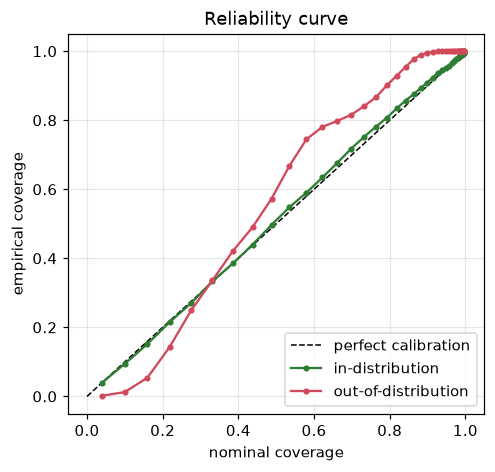

95% interval coverage  in-distribution : 0.95  (well calibrated)
95% interval coverage  out-of-dist     : 1.00  (intervals balloon -> over-conservative)

Gaussian NLL (lower is better)   single model: 11.571   ensemble: -0.373


In [2]:
Phi = lambda z: 0.5*(1 + erf(z/sqrt(2)))          # standard normal CDF (no scipy needed)

def zscores(lo, hi, n=4000):
    X = rng.uniform(lo, hi, n); Y = f(X) + rng.normal(0, noise, n)
    var = ens_epi(X) + sig_a2
    return np.abs(Y - ens_mean(X)) / np.sqrt(var)

z_in, z_ood = zscores(-2, 2), zscores(3, 5)
ts = np.linspace(0.05, 3.0, 40); nominal = np.array([2*Phi(t)-1 for t in ts])
emp_in  = np.array([np.mean(z_in  <= t) for t in ts])
emp_ood = np.array([np.mean(z_ood <= t) for t in ts])

plt.figure(figsize=(4.6, 4.4))
plt.plot([0,1],[0,1], 'k--', lw=1, label="perfect calibration")
plt.plot(nominal, emp_in, '-o', ms=3, color="#2e7d32", label="in-distribution")
plt.plot(nominal, emp_ood, '-o', ms=3, color="#d1495b", label="out-of-distribution")
plt.xlabel("nominal coverage"); plt.ylabel("empirical coverage")
plt.title("Reliability curve"); plt.legend(loc="lower right"); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()
print("95%% interval coverage  in-distribution : %.2f  (well calibrated)" % np.mean(z_in  <= 1.96))
print("95%% interval coverage  out-of-dist     : %.2f  (intervals balloon -> over-conservative)" % np.mean(z_ood <= 1.96))

# proper scoring rule: Gaussian negative log-likelihood, single model vs ensemble
Xte = rng.uniform(-3, 3, 4000); Yte = f(Xte) + rng.normal(0, noise, 4000)
def gauss_nll(mu, var, y): return float(np.mean(0.5*np.log(2*np.pi*var) + 0.5*(y-mu)**2/var))
nll_single = gauss_nll(members[0](Xte), np.full(len(Xte), sig_a2), Yte)   # one model, no epistemic
nll_ens    = gauss_nll(ens_mean(Xte),   ens_epi(Xte) + sig_a2,     Yte)   # ensemble, with epistemic
print("\nGaussian NLL (lower is better)   single model: %.3f   ensemble: %.3f" % (nll_single, nll_ens))

## 5. The failure mode: uncertainty is not error

In the demo above the well-specified ensemble stayed calibrated in-distribution and
turned *conservative* out-of-distribution (coverage 1.00 - the band ballooned): it
correctly widened where it was ignorant. That is the good case, and it is why the
epistemic trace is a useful signal. But note that off-diagonal calibration can go
*either* way, and only one direction is dangerous.

The danger is this: an ensemble only disagrees where its members *can* disagree. If
the members share a limiting assumption - too small a hypothesis class, the same
blind spot - they **agree and are all wrong**: low variance, high error. Uncertainty
then silently underestimates error, and no reliability check on in-distribution data
would reveal it.

Below we cripple the ensemble (very few, shared features; only the bootstrap
differs). The members agree closely, so the reported band is tight - yet the fit is
biased, and in a fraction of the domain the true error lies *outside* the 2-sigma
band. This is the confidently-wrong regime.

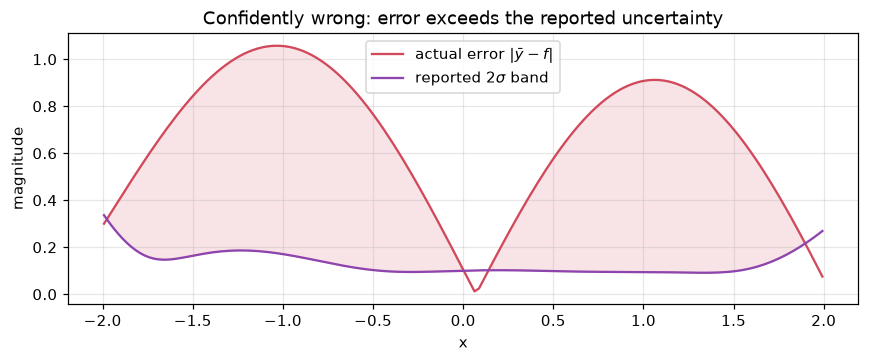

in-domain fraction where actual error exceeds the 2-sigma band: 93%


In [3]:
phi_shared = features(6, seed=7)                  # too few features, shared by all members
weak = [fit_member(phi_shared, Xtr[rng.integers(0, len(Xtr), len(Xtr))], Ytr) for _ in range(25)]
pw = np.stack([m(xs) for m in weak]); muw, stdw = pw.mean(0), pw.std(0)
errw = np.abs(muw - f(xs))
mask = (xs > -2) & (xs < 2)
over = 100*np.mean(errw[mask] > 2*stdw[mask])

plt.figure(figsize=(8, 3.4))
plt.plot(xs[mask], errw[mask], color="#d1495b", label="actual error $|\\bar y - f|$")
plt.plot(xs[mask], 2*stdw[mask], color="#8e44ad", label="reported $2\\sigma$ band")
plt.fill_between(xs[mask], 2*stdw[mask], errw[mask], where=errw[mask] > 2*stdw[mask],
                 color="#d1495b", alpha=.15)
plt.xlabel("x"); plt.ylabel("magnitude"); plt.title("Confidently wrong: error exceeds the reported uncertainty")
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print("in-domain fraction where actual error exceeds the 2-sigma band: %.0f%%" % over)

## 6. Consequences for the driving system

The trace of $\Sigma^{epi}$ is a genuinely useful signal - it rises under blur,
darkness and sparse data, and it feeds the integrity score. But section 5 is the
warning: on a truly novel regime (the out-of-distribution *curve* of notebook 03,
which even looks like a valid image) an over-confident perception network can report
a small covariance while being biased. No amount of introspective uncertainty fixes
this, because the model is judging itself.

The remedy is an **external, model-based** cross-check: compare the perception
output against a physics prediction and test their consistency. That is the Kalman
innovation / NIS test of notebook 05, and it is precisely what catches the case
where uncertainty alone stays quiet.

### Exercises

1. Verify the law of total variance numerically: estimate both terms from the
   ensemble and confirm they sum to the empirical predictive variance in-domain.
2. Grow $M$ from 2 to 50 and plot how the epistemic estimate stabilises. How many
   members are "enough" here?
3. Recalibrate the OOD intervals with a single temperature scalar
   $\sigma\mapsto\tau\sigma$ chosen on a validation set (temperature scaling [9]).
   Does one global $\tau$ fix both in- and out-of-distribution coverage? Why not?
4. Replace the ensemble with MC dropout on a small MLP (if you have torch) and
   compare the reliability curves.

## References

1. A. Der Kiureghian, O. Ditlevsen. *Aleatory or epistemic? Does it matter?* Structural Safety, 31(2):105-112, 2009. doi:10.1016/j.strusafe.2008.06.020
2. E. Huellermeier, W. Waegeman. *Aleatoric and epistemic uncertainty in machine learning: an introduction to concepts and methods.* Machine Learning, 110:457-506, 2021. doi:10.1007/s10994-021-05946-3
3. A. Kendall, Y. Gal. *What Uncertainties Do We Need in Bayesian Deep Learning for Computer Vision?* NeurIPS, 2017. arXiv:1703.04977
4. D. J. C. MacKay. *A Practical Bayesian Framework for Backpropagation Networks.* Neural Computation, 4(3):448-472, 1992. doi:10.1162/neco.1992.4.3.448
5. Y. Gal, Z. Ghahramani. *Dropout as a Bayesian Approximation: Representing Model Uncertainty in Deep Learning.* ICML, 2016. arXiv:1506.02142
6. C. Blundell, J. Cornebise, K. Kavukcuoglu, D. Wierstra. *Weight Uncertainty in Neural Networks.* ICML, 2015. arXiv:1505.05424
7. B. Lakshminarayanan, A. Pritzel, C. Blundell. *Simple and Scalable Predictive Uncertainty Estimation using Deep Ensembles.* NeurIPS, 2017. arXiv:1612.01474
8. S. Fort, H. Hu, B. Lakshminarayanan. *Deep Ensembles: A Loss Landscape Perspective.* arXiv:1912.02757, 2019.
9. C. Guo, G. Pleiss, Y. Sun, K. Q. Weinberger. *On Calibration of Modern Neural Networks.* ICML, 2017. arXiv:1706.04599
10. V. Kuleshov, N. Fenner, S. Ermon. *Accurate Uncertainties for Deep Learning Using Calibrated Regression.* ICML, 2018. arXiv:1807.00263
11. T. Gneiting, A. E. Raftery. *Strictly Proper Scoring Rules, Prediction, and Estimation.* Journal of the American Statistical Association, 102(477):359-378, 2007. doi:10.1198/016214506000001437
12. A. Rahimi, B. Recht. *Random Features for Large-Scale Kernel Machines.* NeurIPS, 2007. (The random-feature regressors used here.)